# Jaccpot GPU Runtime Benchmark (Radix Tree)

This notebook benchmarks Jaccpot runtime on GPU using yggdrax radix-tree settings tuned for throughput.

Included plots:
- `Runtime scaling with particle count (full vs prepared split)`
- `prepare_state component breakdown`

In [1]:
import os

# --- Option A: automatic GPU selection with autocvd ---
USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []

# --- Option B: manual selection (set to string like '0' or '0,1') ---
MANUAL_CUDA_VISIBLE_DEVICES = "0,3"  # None #"1,2,3,4,5,6,7,8,9"#None

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = MANUAL_CUDA_VISIBLE_DEVICES
    print("Set CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd

        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print(
            "autocvd selected CUDA_VISIBLE_DEVICES =",
            os.environ.get("CUDA_VISIBLE_DEVICES"),
        )
    except ImportError:
        print(
            "autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES."
        )
else:
    print(
        "Using existing CUDA visibility:",
        os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"),
    )

Set CUDA_VISIBLE_DEVICES = 0,3


In [2]:
import pathlib
import sys
import inspect

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = pathlib.Path.cwd().resolve()
if not (REPO_ROOT / "jaccpot").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from jaccpot import (
    FMMAdvancedConfig,
    FMMPreset,
    FarFieldConfig,
    FastMultipoleMethod,
    NearFieldConfig,
    RuntimePolicyConfig,
    TreeConfig,
)
from yggdrax import Tree, compute_tree_geometry
from yggdrax.interactions import DualTreeTraversalConfig, build_interactions_and_neighbors

from examples import benchmark_utils as bench_utils

In [3]:
# GPU sanity check
all_devices = jax.devices()
gpu_devices = [d for d in all_devices if d.platform == "gpu"]
print("JAX backend:", jax.default_backend())
print("Visible devices:", all_devices)
if not gpu_devices:
    raise RuntimeError(
        "No GPU device visible to JAX. Ensure CUDA/ROCm is configured before running this notebook."
    )
print("Using GPU:", gpu_devices[0])

JAX backend: gpu
Visible devices: [CudaDevice(id=0), CudaDevice(id=1)]
Using GPU: cuda:0


## Benchmark Configuration

In [4]:
# Particle-count sweep for scaling plots (includes your target N=131072)
runtime_particle_counts = [8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216]
runtime_leaf_size = 64
runtime_max_order = 4
runtime_runs = 3
runtime_warmup = 1

# GPU-oriented dtype
runtime_working_dtype = jnp.float32
runtime_key = jax.random.PRNGKey(0)
softening = 1e-3

# Requested yggdrax radix traversal setup
traversal_cfg = DualTreeTraversalConfig(
    process_block=256,
    max_neighbors_per_leaf=4096,
    max_interactions_per_node=1024,
    max_pair_queue=262_144,
)

runtime_advanced = FMMAdvancedConfig(
    tree=TreeConfig(tree_type="radix", leaf_target=runtime_leaf_size),
    farfield=FarFieldConfig(rotation="solidfmm", mode="auto", grouped_interactions=True),
    nearfield=NearFieldConfig(mode="bucketed", edge_chunk_size=256),
    runtime=RuntimePolicyConfig(
        pair_process_block=256,
        traversal_config=traversal_cfg,
        jit_traversal=True,
    ),
    mac_type="dehnen",
)

runtime_fmm_kwargs = dict(
    preset=FMMPreset.FAST,
    basis="solidfmm",
    theta=0.6,
    softening=softening,
    working_dtype=runtime_working_dtype,
    advanced=runtime_advanced,
)

## Runtime Collection Helpers

In [5]:
def _evaluate_prepared_kwargs(fmm):
    params = inspect.signature(fmm.evaluate_prepared_state).parameters
    if "jit_traversal" in params:
        return {"jit_traversal": True}
    return {}


def _release_runtime_memory(fmm):
    clear_fn = getattr(fmm, "clear_runtime_caches", None)
    if callable(clear_fn):
        clear_fn(clear_jax_compilation=True)
        return
    if hasattr(fmm, "clear_prepared_state_cache"):
        fmm.clear_prepared_state_cache()
    jax.clear_caches()


def sweep_runtimes(
    particle_counts,
    *,
    leaf_size,
    max_order,
    runs,
    warmup,
    dtype,
    key,
    fmm_kwargs,
    strict=False,
):
    records = []
    fmm = FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    for num_particles in particle_counts:
        try:
            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            full_timing = bench_utils.time_callable(
                fmm.compute_accelerations,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                reuse_prepared_state=False,
                warmup=warmup,
                runs=runs,
            )

            prepare_once_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=leaf_size,
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )
            prepared_state = prepare_once_timing.result

            eval_kwargs = _evaluate_prepared_kwargs(fmm)
            eval_timing = bench_utils.time_callable(
                fmm.evaluate_prepared_state,
                prepared_state,
                warmup=warmup,
                runs=runs,
                **eval_kwargs,
            )

            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": full_timing.mean,
                    "std_seconds": full_timing.std,
                    "prepare_mean_seconds": prepare_once_timing.mean,
                    "prepare_std_seconds": prepare_once_timing.std,
                    "evaluate_mean_seconds": eval_timing.mean,
                    "evaluate_std_seconds": eval_timing.std,
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[sweep_runtimes] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "mean_seconds": float("nan"),
                    "std_seconds": float("nan"),
                    "prepare_mean_seconds": float("nan"),
                    "prepare_std_seconds": float("nan"),
                    "evaluate_mean_seconds": float("nan"),
                    "evaluate_std_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
        finally:
            _release_runtime_memory(fmm)

    return pd.DataFrame(records)


def profile_prepare_components(
    particle_counts,
    *,
    leaf_size,
    max_order,
    dtype,
    key,
    fmm_kwargs,
    runs,
    warmup,
    strict=False,
):
    records = []
    fmm = FastMultipoleMethod(**fmm_kwargs)
    current_key = key

    tree_type = str(getattr(fmm._impl, "tree_type", "radix"))
    tree_mode = str(getattr(fmm._impl, "tree_build_mode", "lbvh"))
    ygg_build_mode = "fixed_depth" if tree_mode == "fixed_depth" else "adaptive"
    theta_val = float(getattr(fmm._impl, "theta", fmm_kwargs.get("theta", 0.6)))
    traversal_cfg = fmm.advanced.runtime.traversal_config
    mac_type = str(getattr(fmm, "mac_type", "dehnen"))
    dehnen_radius_scale = float(getattr(fmm._impl, "dehnen_radius_scale", 1.0))

    for num_particles in particle_counts:
        try:
            positions, masses, current_key = bench_utils.generate_random_distribution(
                num_particles,
                key=current_key,
                dtype=dtype,
            )

            tree_timing = bench_utils.time_callable(
                Tree.from_particles,
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
                warmup=warmup,
                runs=runs,
            )

            tree = Tree.from_particles(
                positions,
                masses,
                tree_type=tree_type,
                build_mode=ygg_build_mode,
                return_reordered=True,
                leaf_size=int(leaf_size),
            )
            geometry = compute_tree_geometry(tree, tree.positions_sorted)

            interactions_timing = bench_utils.time_callable(
                build_interactions_and_neighbors,
                tree,
                geometry,
                theta=theta_val,
                traversal_config=traversal_cfg,
                mac_type=mac_type,
                dehnen_radius_scale=dehnen_radius_scale,
                warmup=warmup,
                runs=runs,
            )

            prepare_timing = bench_utils.time_callable(
                fmm.prepare_state,
                positions,
                masses,
                leaf_size=int(leaf_size),
                max_order=max_order,
                warmup=warmup,
                runs=runs,
            )

            residual = max(
                float(prepare_timing.mean)
                - float(tree_timing.mean)
                - float(interactions_timing.mean),
                0.0,
            )
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float(tree_timing.mean),
                    "interactions_mean_seconds": float(interactions_timing.mean),
                    "upward_mean_seconds": residual,
                    "downward_mean_seconds": 0.0,
                    "prepare_component_sum_seconds": float(prepare_timing.mean),
                    "error": "",
                }
            )
        except Exception as exc:
            msg = f"{type(exc).__name__}: {exc}"
            print(f"[profile_prepare_components] N={num_particles} failed: {msg}")
            records.append(
                {
                    "num_particles": num_particles,
                    "tree_build_mean_seconds": float("nan"),
                    "upward_mean_seconds": float("nan"),
                    "interactions_mean_seconds": float("nan"),
                    "downward_mean_seconds": float("nan"),
                    "prepare_component_sum_seconds": float("nan"),
                    "error": msg,
                }
            )
            if strict:
                raise
        finally:
            _release_runtime_memory(fmm)

    return pd.DataFrame(records)

## Runtime Scaling (Full vs Prepared Split)

In [ ]:
runtime_df = sweep_runtimes(
    runtime_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    runs=runtime_runs,
    warmup=runtime_warmup,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_fmm_kwargs,
)
runtime_df_sorted = runtime_df.sort_values("num_particles")
runtime_df_sorted

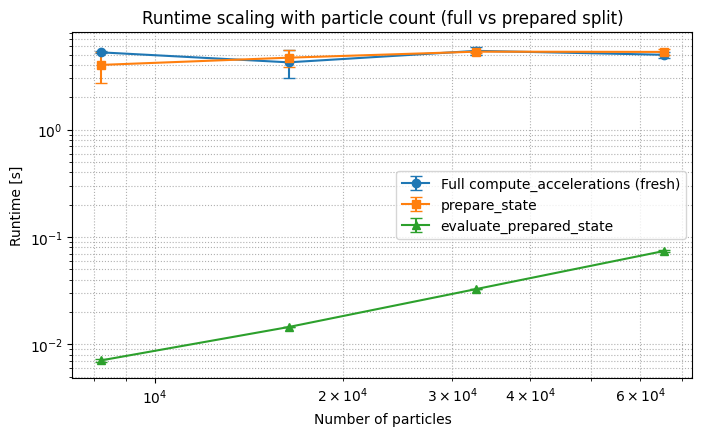

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.errorbar(
    runtime_df_sorted["num_particles"],
    runtime_df_sorted["mean_seconds"],
    yerr=runtime_df_sorted["std_seconds"],
    fmt="o-",
    capsize=4,
    label="Full compute_accelerations (fresh)",
)
ax.errorbar(
    runtime_df_sorted["num_particles"],
    runtime_df_sorted["prepare_mean_seconds"],
    yerr=runtime_df_sorted["prepare_std_seconds"],
    fmt="s-",
    capsize=4,
    label="prepare_state",
)
ax.errorbar(
    runtime_df_sorted["num_particles"],
    runtime_df_sorted["evaluate_mean_seconds"],
    yerr=runtime_df_sorted["evaluate_std_seconds"],
    fmt="^-",
    capsize=4,
    label="evaluate_prepared_state",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("Runtime scaling with particle count (full vs prepared split)")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()

## Prepare-State Component Breakdown

In [ ]:
runtime_component_df = profile_prepare_components(
    runtime_particle_counts,
    leaf_size=runtime_leaf_size,
    max_order=runtime_max_order,
    dtype=runtime_working_dtype,
    key=runtime_key,
    fmm_kwargs=runtime_fmm_kwargs,
    runs=max(1, runtime_runs),
    warmup=runtime_warmup,
)
runtime_component_df

[profile_prepare_components] N=8192 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to get module function: CUDA_ERROR_OUT_OF_MEMORY: out of memory
[profile_prepare_components] N=16384 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to get module function: CUDA_ERROR_OUT_OF_MEMORY: out of memory
[profile_prepare_components] N=32768 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to get module function: CUDA_ERROR_OUT_OF_MEMORY: out of memory
[profile_prepare_components] N=65536 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to get module function: CUDA_ERROR_OUT_OF_MEMORY: out of memory
[profile_prepare_components] N=131072 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to get module function: CUDA_ERROR_OUT_OF_MEMORY: out of memory
[profile_prepare_components] N=262144 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to get module function: CUDA_ERROR_OUT_OF_MEMORY: out of memory
[profile_prepare_components] N=524288 failed: JaxRuntimeE

W0306 21:01:49.998616  113860 cuda_command_buffer.cc:777] Retry CUDA graph instantiation after OOM error


[profile_prepare_components] N=1048576 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: Underlying backend ran out of memory trying to instantiate command buffer with 68 (total of 7 alive graphs in the process). You can try to (a) Give more memory to the driver by reducing XLA_CLIENT_MEM_FRACTION (b) Disable command buffers with 'XLA_FLAGS=--xla_gpu_enable_command_buffer=' (empty set). Original error: Failed to instantiate CUDA graph: CUDA_ERROR_OUT_OF_MEMORY: out of memory
[profile_prepare_components] N=2097152 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to get module function: CUDA_ERROR_OUT_OF_MEMORY: out of memory
[profile_prepare_components] N=4194304 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to get module function: CUDA_ERROR_OUT_OF_MEMORY: out of memory
[profile_prepare_components] N=8388608 failed: JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to get module function: CUDA_ERROR_OUT_OF_MEMORY: out of memory
[profile_prepare_components] N=16777216 failed: 

W0306 21:01:56.713026  114336 autotuner.cc:583] No reference output found even though buffer checking was requested while autotuning
W0306 21:01:56.716738  114348 autotuner.cc:583] No reference output found even though buffer checking was requested while autotuning


,num_particles,tree_build_mean_seconds,upward_mean_seconds,interactions_mean_seconds,downward_mean_seconds,prepare_component_sum_seconds,error
0,8192,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Faile...
1,16384,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Faile...
2,32768,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Faile...
3,65536,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Faile...
4,131072,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Faile...
5,262144,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Faile...
6,524288,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Faile...
7,1048576,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: Underlyin...
8,2097152,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Faile...
9,4194304,NaN,NaN,NaN,NaN,NaN,JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Faile...


In [ ]:
runtime_component_sorted = runtime_component_df.sort_values("num_particles")

fig, ax = plt.subplots(figsize=(8, 4.5))
for col, label, marker in [
    ("tree_build_mean_seconds", "tree build", "o"),
    ("upward_mean_seconds", "upward", "s"),
    ("interactions_mean_seconds", "interactions", "^"),
    ("downward_mean_seconds", "downward", "d"),
    ("prepare_component_sum_seconds", "component sum", "x"),
]:
    ax.plot(
        runtime_component_sorted["num_particles"],
        runtime_component_sorted[col],
        marker=marker,
        label=label,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of particles")
ax.set_ylabel("Runtime [s]")
ax.set_title("prepare_state component breakdown")
ax.grid(True, which="both", linestyle=":", linewidth=0.8)
ax.legend()
plt.show()

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 800x450 with 1 Axes>

## Notes

- This notebook is GPU-focused and will fail early if no GPU is visible to JAX.
- The traversal configuration is fixed to:
  - `leaf_size=64`
  - `process_block=256`
  - `max_neighbors_per_leaf=4096`
  - `max_interactions_per_node=1024`
  - `max_pair_queue=262_144`
- The scaling sweep includes `N=131072` as requested.